In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

# Dataset path
DATA_DIR = "../data/chest_xray"

# Image settings
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

print("Setup complete!")

TensorFlow version: 2.21.0
Setup complete!


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=42
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']
Train batches: 163
Val batches: 1
Test batches: 20


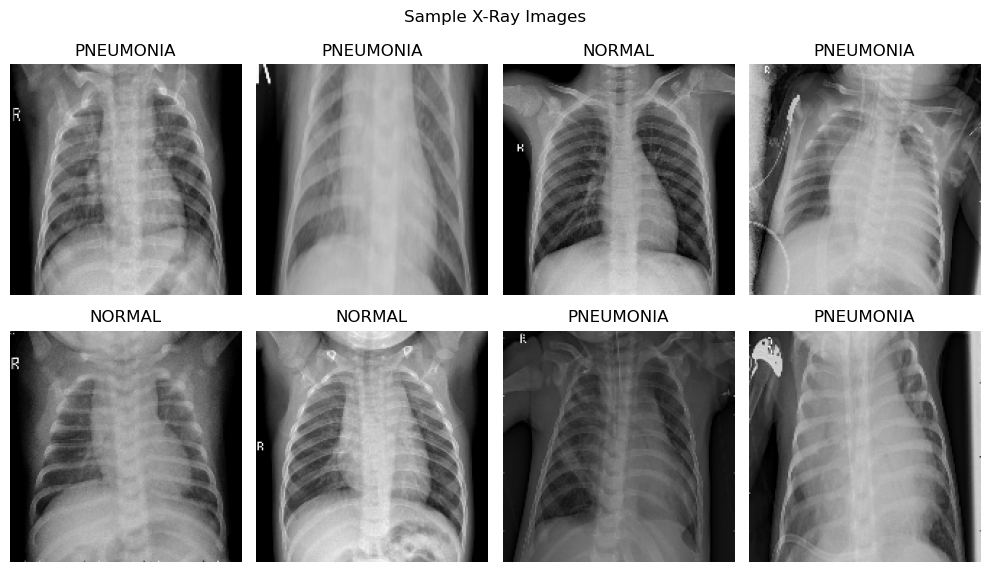

In [9]:
# Just for checking that correct dataset is loaded


plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i][0])])
        plt.axis("off")
plt.suptitle("Sample X-Ray Images")
plt.tight_layout()
plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(200).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Dataset optimized!")

Dataset optimized!


In [11]:
model = tf.keras.Sequential([
    # Rescaling (0-255 pixels ko 0-1 range mein convert karna)
    tf.keras.layers.Rescaling(1./255, input_shape=(160, 160, 3)),
    
    # Convolution layers - image se patterns learn karta hai
    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    
    # Flatten and classify
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\mailm\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 160, 160, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 80, 80, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 80, 80, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 40, 40, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 40, 40, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\mailm\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 203ms/step - accuracy: 0.7418 - loss: 0.5874 - val_accuracy: 0.5000 - val_loss: 0.7574
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.7448 - loss: 0.4933 - val_accuracy: 0.5000 - val_loss: 0.8489
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.7742 - loss: 0.4455 - val_accuracy: 0.8125 - val_loss: 0.6756
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.8200 - loss: 0.3996 - val_accuracy: 0.5625 - val_loss: 0.7609
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.8568 - loss: 0.3535 - val_accuracy: 0.5625 - val_loss: 0.7561
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.8723 - loss: 0.3112 - val_accuracy: 0.6250 - val_loss: 0.6256
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.8762 - loss: 0.2981 - val_accuracy: 0.6875 - val_loss: 0.6311
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 190ms/step - accuracy: 0.8831 - loss: 0.2748 - val

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.7612 - loss: 0.5843

Test Accuracy: 76.12%
Test Loss: 0.5843


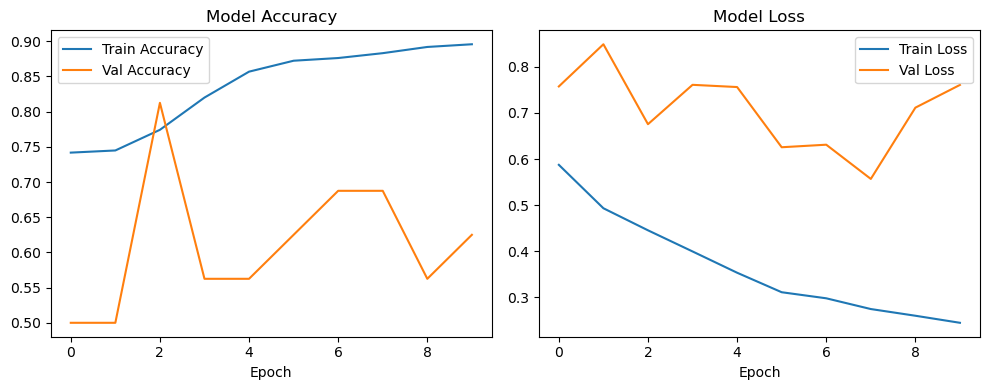

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Load MobileNet base model with pretrained ImageNet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model weights (we don't want to change them)
base_model.trainable = False

# Add our own classification layer on top
inputs = tf.keras.Input(shape=(160, 160, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Transfer Learning model ready!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Transfer Learning model ready!


In [16]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 518ms/step - accuracy: 0.8671 - loss: 0.3134 - val_accuracy: 0.8750 - val_loss: 0.2620
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.9340 - loss: 0.1651 - val_accuracy: 0.8125 - val_loss: 0.3861
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.9463 - loss: 0.1332 - val_accuracy: 0.8750 - val_loss: 0.3242
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 296ms/step - accuracy: 0.9540 - loss: 0.1182 - val_accuracy: 0.8750 - val_loss: 0.2344
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9603 - loss: 0.1085 - val_accuracy: 0.8750 - val_loss: 0.2429
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 290ms/step - accuracy: 0.9617 - loss: 0.1020 - val_accuracy: 0.9375 - val_loss: 0.2102
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.9618 - loss: 0.1011 - val_accuracy: 0.9375 - val_loss: 0.2154
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.9636 - loss: 

In [17]:
test_loss, test_accuracy = transfer_model.evaluate(test_ds)
print(f"\nScratch CNN Test Accuracy:   76.12%")
print(f"MobileNet Test Accuracy:     {test_accuracy:.2%}")
print(f"MobileNet Test Loss:         {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.8157 - loss: 0.5243

Scratch CNN Test Accuracy:   76.12%
MobileNet Test Accuracy:     81.57%
MobileNet Test Loss:         0.5243


In [18]:
import os
os.makedirs("../models", exist_ok=True)
transfer_model.save("../models/xray_model.keras")
print("X-ray model saved!")

X-ray model saved!
